In [1]:
# =========================================================
# Standard library
# =========================================================
import os
import sys
import importlib
from pathlib import Path

# =========================================================
# Make local SIDM package importable
# =========================================================
def find_repo_root(start=None, repo_hint="SIDM_fresh"):
    """
    Find the repo root containing the local `sidm/` package.

    Handles both cases:
      1. Notebook is already inside the repo.
      2. Notebook starts from CMSSW src/ and repo is a child directory.
    """
    start = Path(start or os.getcwd()).resolve()

    # Search current directory and parents
    for path in [start, *start.parents]:
        if (path / "sidm").is_dir():
            return path

    # Search one level below current directory, useful from CMSSW src/
    for child in start.iterdir():
        if child.is_dir() and (child / "sidm").is_dir():
            return child

    # Try known repo name directly
    hinted = start / repo_hint
    if (hinted / "sidm").is_dir():
        return hinted

    raise RuntimeError(
        f"Could not find a `sidm/` directory from {start}. "
        "Check your repo location with `!find . -maxdepth 3 -type d -name sidm`."
    )


REPO_ROOT = find_repo_root()

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(f"Using SIDM repo root: {REPO_ROOT}")

# Optional but helpful: make relative paths behave as expected
os.chdir(REPO_ROOT)
print(f"Current working directory: {Path.cwd()}")

# =========================================================
# Columnar analysis
# =========================================================
import awkward as ak
import numpy as np
import coffea.util
from coffea import processor

# =========================================================
# Local SIDM imports
# =========================================================
from sidm.tools import (
    utilities,
    sidm_processor,
    scaleout,
    cutflow,
    llpnanoaodschema,
)

# Reload local modules during development
for module in (
    utilities,
    sidm_processor,
    scaleout,
    cutflow,
    llpnanoaodschema,
):
    importlib.reload(module)

# =========================================================
# Plotting / notebook utilities
# =========================================================
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

utilities.set_plot_style()
%matplotlib inline

Using SIDM repo root: /uscms_data/d3/scampbel/CMSSW_14_1_0_pre4/src/SIDM_fresh
Current working directory: /uscms_data/d3/scampbel/CMSSW_14_1_0_pre4/src/SIDM_fresh


/uscms/home/scampbel/nobackup/CMSSW_14_1_0_pre4/src/SIDM_fresh/.python_userbase/lib/python3.9/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/uscms/home/scampbel/nobackup/CMSSW_14_1_0_pre4/src/SIDM_fresh/.python_userbase/lib/python3.9/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  return self._float_to_str(self.smallest_subnormal)
/uscms/home/scampbel/nobackup/CMSSW_14_1_0_pre4/src/SIDM_fresh/.python_userbase/lib/python3.9/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/uscms/home/scampbel/nobackup/CMSSW_14_1_0_pre4/src/SIDM_fresh/.python_userbase/lib/python3.9/site-packages/numpy/core/getlimits.py:89: UserWarning: The value

In [2]:
samples = [
    ### 200 GeV Samples
    '2Mu2E_200GeV_0p25GeV_0p1mm',
]
fileset = utilities.make_fileset(samples, 
                                 "llpNanoAOD_v2", 
                                 location_cfg="signal_2mu2e_v10.yaml",
                                 max_files = 1,
                                 replace_xcache=True,
                                )

In [3]:
"""Analysis-specific debug branches for SidmProcessor.

These are passed to SidmProcessor through the `debug_branches` argument; they are
NOT part of the generic processor. Each branch is a function taking
(sel_objs, events) and returning a per-event array.

Branches are filtered by the processor's final event mask by default.

Use `_full_chunk_branch(...)` for branches that should NOT be event-filtered,
such as raw Generator weights needed for histogram scaling.

Usage:
    from sidm.<wherever_you_put_this>.debug_branches import sidm_debug_branches

    p = SidmProcessor(
        channel_names,
        hist_collection_names,
        debug=True,
        debug_branches=sidm_debug_branches(),
        include_default_debug_branches=False,
    )

Read results after running with:
    debug = out[dataset]["debug"][lj_reco][channel]
    arrays = {name: acc.value for name, acc in debug.items()}

This is just a demo on how to add your own debug branches. This is from my background estimation study
"""


def _full_chunk_branch(func):
    """Mark a debug branch as intentionally unfiltered by event selection.

    The SidmProcessor checks for `branch_func.no_selection == True`.
    """
    func.no_selection = True
    return func


def sidm_debug_branches():
    """Return the analysis-specific debug branch dictionary."""

    def mu0(sel_objs):
        return ak.firsts(sel_objs["mu_ljs"])

    def egm0(sel_objs):
        return ak.firsts(sel_objs["egm_ljs"])

    def lj0(sel_objs):
        return ak.firsts(sel_objs["ljs"])

    def lj1(sel_objs):
        return ak.firsts(sel_objs["ljs"][:, 1:2])

    return {
        # =========================================================
        # Muon-EGM LJ ABCD variables
        # These are selected-event branches and will be masked.
        # =========================================================
        "mu_lj_iso": lambda sel_objs, events: mu0(sel_objs).isolation,
        "egm_lj_iso": lambda sel_objs, events: egm0(sel_objs).isolation,
        "dPhi": lambda sel_objs, events: abs(
            mu0(sel_objs).delta_phi(egm0(sel_objs))
        ),
        "mJJ": lambda sel_objs, events: (
            mu0(sel_objs) + egm0(sel_objs)
        ).mass,
        "dR": lambda sel_objs, events: abs(
            mu0(sel_objs).delta_r(egm0(sel_objs))
        ),
        "deltaEta": lambda sel_objs, events: abs(
            mu0(sel_objs).eta - egm0(sel_objs).eta
        ),

        # =========================================================
        # Muon LJ details
        # =========================================================
        "dsaMu_n": lambda sel_objs, events: mu0(sel_objs).dsaMu_n,
        "pfMu_n": lambda sel_objs, events: mu0(sel_objs).pfMu_n,
        "mu_lj_min_dxy": lambda sel_objs, events: ak.min(
            abs(mu0(sel_objs).muons.dxy),
            axis=-1,
        ),
        "mu_lj_max_dxy": lambda sel_objs, events: ak.max(
            abs(mu0(sel_objs).muons.dxy),
            axis=-1,
        ),
        "pixelHits": lambda sel_objs, events: ak.max(
            mu0(sel_objs).pfMuons.trkNumPixelHits,
            axis=-1,
        ),
        "trkHits": lambda sel_objs, events: ak.max(
            mu0(sel_objs).pfMuons.trkNumTrkLayers,
            axis=-1,
        ),

        # =========================================================
        # Muon LJ kinematics
        # =========================================================
        "mu_lj_pt": lambda sel_objs, events: mu0(sel_objs).pt,
        "mu_lj_eta": lambda sel_objs, events: mu0(sel_objs).eta,
        "mu_lj_phi": lambda sel_objs, events: mu0(sel_objs).phi,

        # =========================================================
        # EGM LJ kinematics
        # =========================================================
        "egm_lj_pt": lambda sel_objs, events: egm0(sel_objs).pt,
        "egm_lj_eta": lambda sel_objs, events: egm0(sel_objs).eta,
        "egm_lj_phi": lambda sel_objs, events: egm0(sel_objs).phi,

        # =========================================================
        # Generic leading/subleading LJ variables
        # =========================================================
        "leading_lj_isolation": lambda sel_objs, events: lj0(sel_objs).isolation,
        "subleading_lj_isolation": lambda sel_objs, events: lj1(sel_objs).isolation,
        "4mu_dPhi": lambda sel_objs, events: abs(
            lj0(sel_objs).delta_phi(lj1(sel_objs))
        ),
        "4mu_mJJ": lambda sel_objs, events: (
            lj0(sel_objs) + lj1(sel_objs)
        ).mass,

        # =========================================================
        # Leading generic LJ constituent counts
        # =========================================================
        "Leading_pfMu_n": lambda sel_objs, events: lj0(sel_objs).pfMu_n,
        "Leading_dsaMu_n": lambda sel_objs, events: lj0(sel_objs).dsaMu_n,
        "Leading_pixelHits": lambda sel_objs, events: ak.max(
            lj0(sel_objs).pfMuons.trkNumPixelHits,
            axis=-1,
        ),

        # =========================================================
        # Subleading generic LJ constituent counts
        # =========================================================
        "SubLeading_pfMu_n": lambda sel_objs, events: lj1(sel_objs).pfMu_n,
        "SubLeading_dsaMu_n": lambda sel_objs, events: lj1(sel_objs).dsaMu_n,
        "SubLeading_pixelHits": lambda sel_objs, events: ak.max(
            lj1(sel_objs).pfMuons.trkNumPixelHits,
            axis=-1,
        ),

        # =========================================================
        # Selected-event weights
        # This branch WILL be masked by the processor.
        # =========================================================
        "passing_weights": lambda sel_objs, events: sel_objs["evt_weights"],

        # =========================================================
        # Full-chunk generator weights
        # This branch will NOT be masked by the processor.
        # Needed for sum-of-weights / histogram scaling.
        # =========================================================
        "gen_weights": _full_chunk_branch(
            lambda sel_objs, events: (
                events.Generator.weight
                if hasattr(events, "Generator")
                else ak.Array([])
            )
        ),
    }

In [4]:
runner = processor.Runner(
    #executor=processor.DaskExecutor(client=client),
    executor=processor.IterativeExecutor(),
    #executor=processor.FuturesExecutor(workers=10),
    schema=llpnanoaodschema.LLPNanoAODSchema,
    skipbadfiles=True
)

channels = [
    "base",
]

p = sidm_processor.SidmProcessor(
    channels,
    ["muon_base"],
    unweighted_hist=True,
    debug=True,
    debug_branches=sidm_debug_branches(),
    include_default_debug_branches=False,  # this dict already has passing_weights
)

out = {}
    
output = runner.run(fileset, treename='Events', processor_instance=p)

#Add this sample's output to the out variable
out = output["out"] 

Output()

Output()

/uscms/home/scampbel/nobackup/CMSSW_14_1_0_pre4/src/SIDM_fresh/.python_userbase/lib/python3.9/site-packages/coffea/
nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => 
Electron
  warnings.warn(

/uscms/home/scampbel/nobackup/CMSSW_14_1_0_pre4/src/SIDM_fresh/.python_userbase/lib/python3.9/site-packages/coffea/
nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => 
Photon
  warnings.warn(

/uscms/home/scampbel/nobackup/CMSSW_14_1_0_pre4/src/SIDM_fresh/.python_userbase/lib/python3.9/site-packages/awkward
/_nplikes/array_module.py:292: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))

Warning: Unable to apply all for nested dsaMuons collection. Skipping.... no field named 'good_matched_muons'

#--------------------------------------------------------------------------
#                         FastJet release 3.4.3
#                 M. Cacciari, G.P. Salam and G. Soyez                  
#     A software package for jet finding and analysis at colliders      
#                           http://fastjet.fr                           
#	                                                                      
# Please cite EPJC72(2012)1896 [arXiv:1111.6097] if you use this package
# for scientific work and optionally PLB641(2006)57 [hep-ph/0512210].   
#                                                                       
# FastJet is provided without warranty under the GNU GPL v2 or higher.  
# It uses T. Chan's closest pair algorithm, S. Fortune's Voronoi code,
# CGAL and 3rd party plugin jet algorithms. See COPYING file for details.
#--------------------------------------------------------------------------


2Mu2E_200GeV_0p25GeV_0p1mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb


In [5]:
debug = out['2Mu2E_200GeV_0p25GeV_0p1mm']['debug']['0.4']['base']
debug.keys()

dict_keys(['mu_lj_iso', 'egm_lj_iso', 'dPhi', 'mJJ', 'dR', 'deltaEta', 'dsaMu_n', 'pfMu_n', 'mu_lj_min_dxy', 'mu_lj_max_dxy', 'pixelHits', 'trkHits', 'mu_lj_pt', 'mu_lj_eta', 'mu_lj_phi', 'egm_lj_pt', 'egm_lj_eta', 'egm_lj_phi', 'leading_lj_isolation', 'subleading_lj_isolation', '4mu_dPhi', '4mu_mJJ', 'Leading_pfMu_n', 'Leading_dsaMu_n', 'Leading_pixelHits', 'SubLeading_pfMu_n', 'SubLeading_dsaMu_n', 'SubLeading_pixelHits', 'passing_weights', 'gen_weights'])

In [6]:
mu_lj_iso = debug['mu_lj_iso'].value

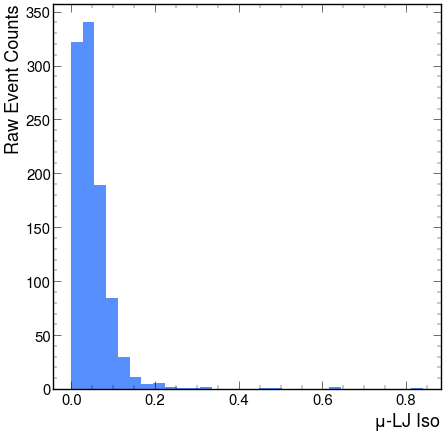

In [7]:
plt.hist(mu_lj_iso, bins=30)
plt.xlabel(rf"$\mu$-LJ Iso")
plt.ylabel("Raw Event Counts")
plt.show()